# Lecture 15 - Exercise - Explore the noisy detector signal

In [612]:
#-------------------------------------------------------------------------
# importing libraries and setting up nice plots
#-------------------------------------------------------------------------

import os
import time
import corner
import requests
import numpy                        as np
import matplotlib                   as mpl
import matplotlib.pyplot            as plt
import matplotlib.patches           as patches
from   matplotlib                   import rc
from   matplotlib.colors            import to_hex
from   mpl_toolkits.axes_grid1      import make_axes_locatable
from   sys                          import stdout
from   scipy                        import stats, integrate
from   astroML                      import stats as astroMLstats
from   astropy.visualization.hist   import hist  as fancyhist
from   astropy.cosmology            import Planck15
from   sklearn.neighbors            import KernelDensity
from   sklearn.manifold             import Isomap
from   sklearn.cluster              import KMeans
from   sklearn.neighbors            import KNeighborsClassifier
from   sklearn.metrics              import confusion_matrix, accuracy_score
from   sklearn.model_selection      import train_test_split, GridSearchCV
from   sklearn.linear_model         import LogisticRegression
from   sklearn.mixture              import GaussianMixture
from   sklearn.decomposition        import PCA, NMF, FastICA

#-------------------------------------------------------------------------

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif" : ["Times New Roman"],
	"font.size"  : 9,
    "figure.dpi" : 300
    })
plt.rc('text.latex', preamble=r'\usepackage{amssymb}')

current_pwd = os.getcwd()
print(current_pwd)

#-------------------------------------------------------------------------

D:\Documents\University\Magistrale\Statistics\GitHub\working


In [613]:
#-------------------------------------------------------------------------
# Load data
#-------------------------------------------------------------------------

signal = np.load('noisydetector.npy')
print(signal.shape)

# the x_axis wasn't included in "noisydetector.npy" but it's part of the exercise
time = np.linspace(0, 8, signal.shape[0])    
print(time.shape)

#-------------------------------------------------------------------------

(2000, 3)
(2000,)


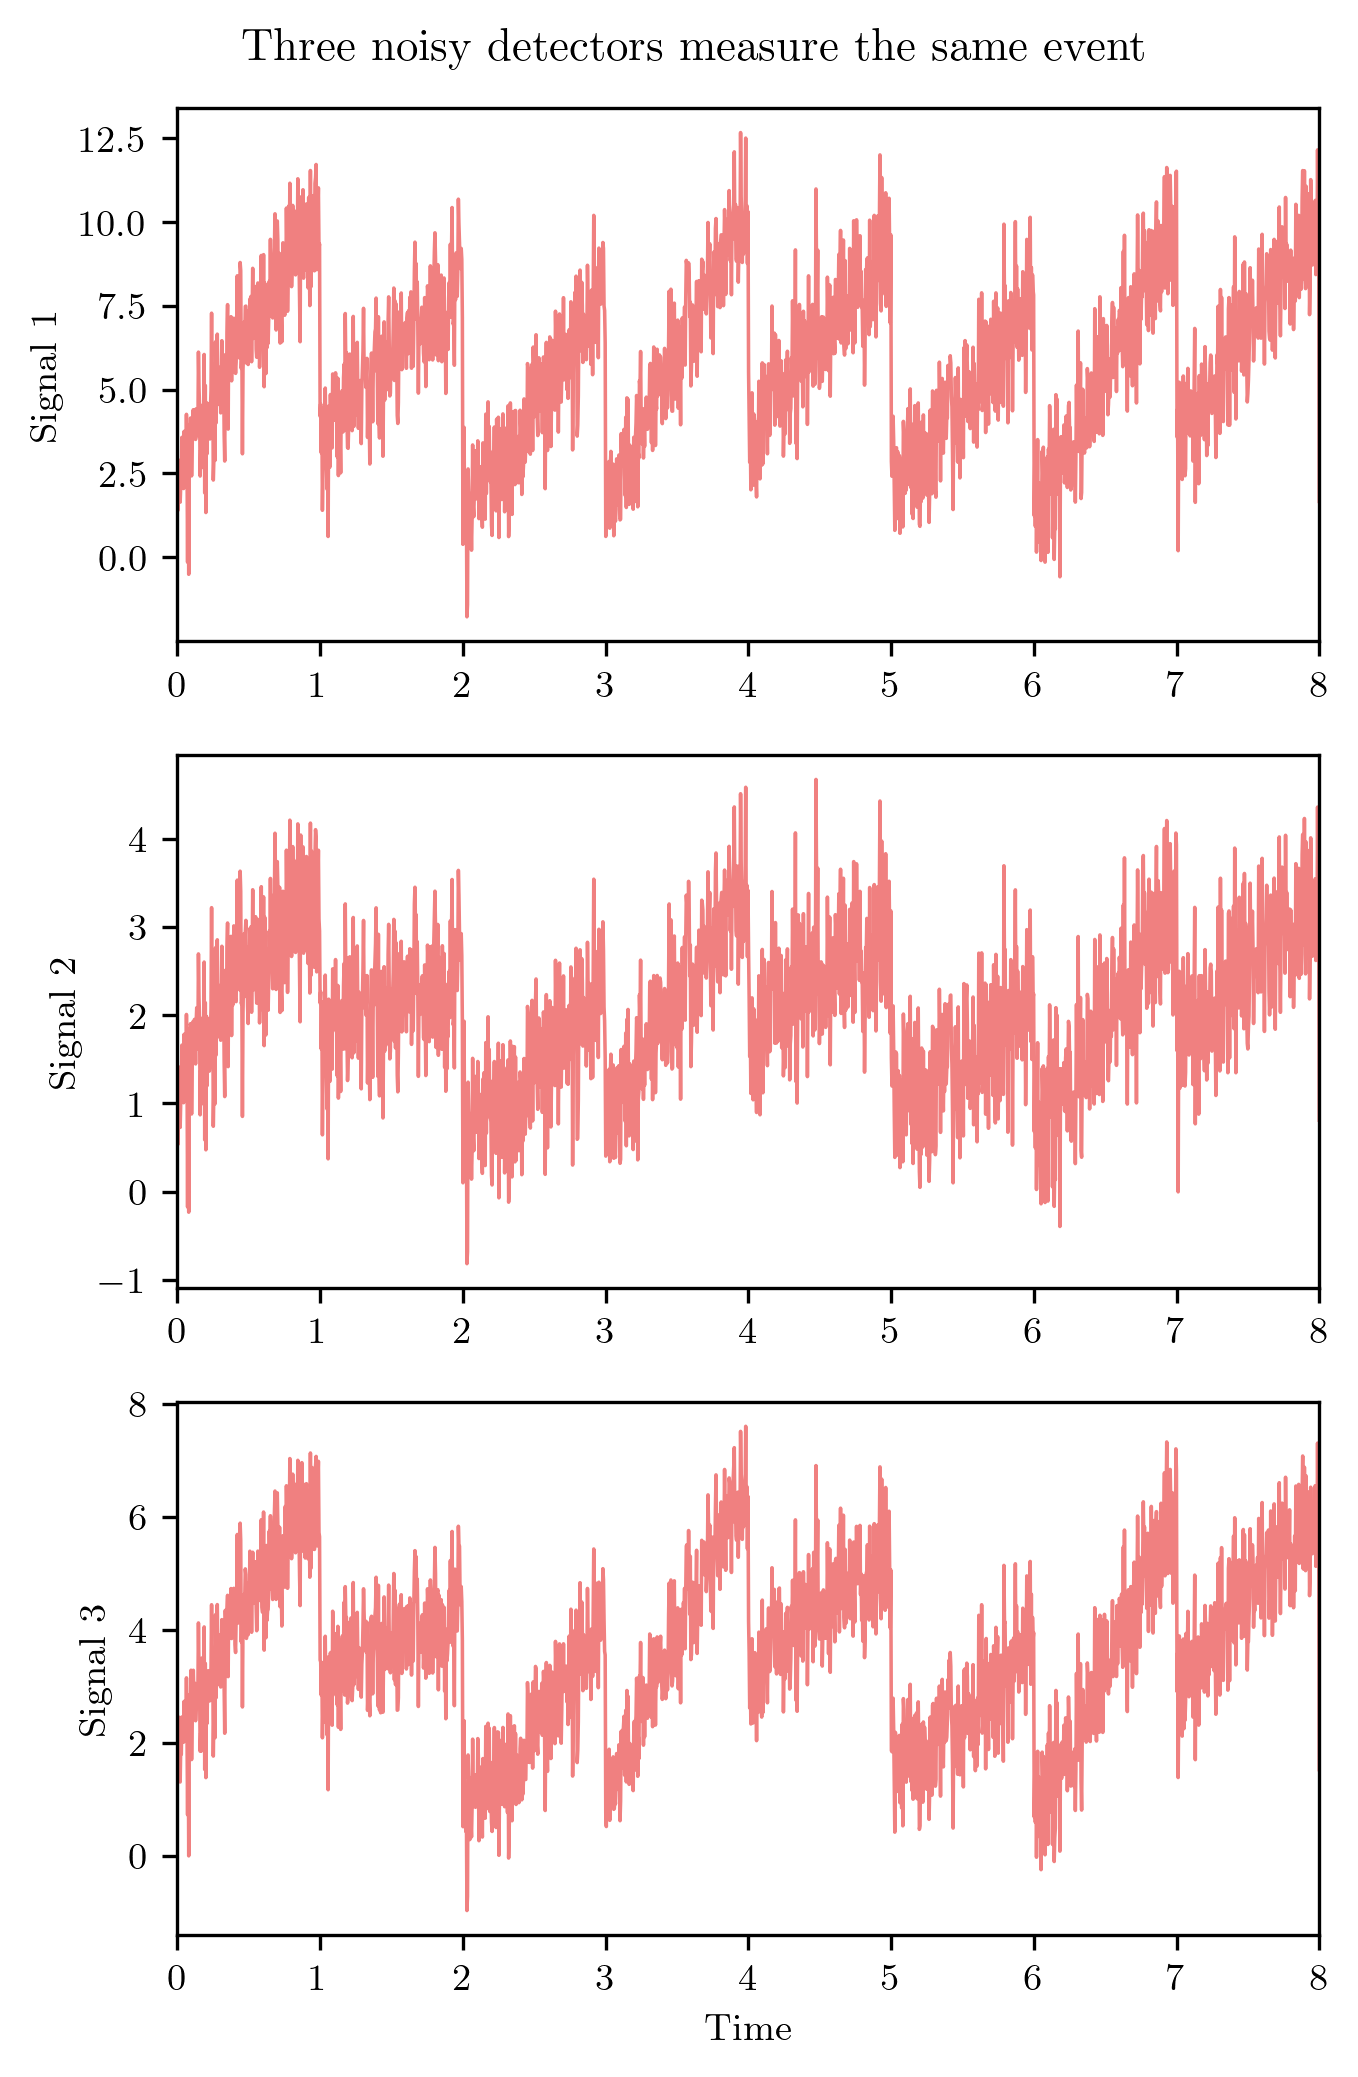

In [614]:
#-------------------------------------------------------------------------
# plot the three measured noisy signals
#-------------------------------------------------------------------------

fig, ax = plt.subplots(3,1,figsize=(4.5,7))
ax = ax.reshape(3)

for i in range(3):
    ax[i].set_xlim(0,8)
    ax[i].plot(time, signal[:,i], color='lightcoral', lw=0.85)
    ax[i].set_ylabel('Signal {:d}'.format(i+1))
ax[-1].set_xlabel('Time')
fig.suptitle('Three noisy detectors measure the same event')
fig.tight_layout()

#-------------------------------------------------------------------------

In [615]:
#-------------------------------------------------------------------------
# Let us now define the various techniques for dimensionality reduction
#-------------------------------------------------------------------------

#-------------------------------------------------------------------------
# Principal Component Anlaysis (isolating mean)
# n_samples = 2000 (number of measurements done by each telescope), 
# n_features = 3 (number of telescopes simultaneously measuring a value) 

def decompose_PCA(data, n_components=3):

    pca = PCA(n_components)
    data_eigenvalues = pca.fit_transform(data)
    data_components = pca.components_
    data_eigenfava = pca.explained_variance_ratio_  
    n_comps = pca.n_components_
    data_mean = data.mean(axis=1)

    return n_comps, data_components, data_eigenvalues, data_eigenfava, data_mean


#-------------------------------------------------------------------------
# Non-negative Matrix Factorization

def decompose_NMF(data, n_components=3):       
    # data X = WY  Y = matrix with the n_comp vector (the positive components)

    dataset = np.copy(data)
    dataset[dataset<0]=0
    nmf = NMF(n_components)
    data_eigenvalues = nmf.fit_transform(dataset)
    data_components  = nmf.components_
    n_comps          = nmf.n_components_

    return n_comps, data_components, data_eigenvalues

#-------------------------------------------------------------------------
# Independent Component Analysis

def decompose_ICA(data, n_components=3):

    ica = FastICA(n_components)
    data_eigenvalues = ica.fit_transform(data)
    data_components  = ica.components_
    data_mixing      = ica.mixing_
    data_mean        = ica.mean_
    n_comps          = n_components

    return n_comps, data_components, data_eigenvalues, data_mixing

#-------------------------------------------------------------------------

Note: scikit learn wants data.shape = (N_samples, N_features). 

In lecture 15 we treated the data as: 
- N_features = 1000 values of a wavefunction at the 1000 different wavelengths.
- N_samples = 4000 individual wavefunctions


There, the purpose was finding some (between 8 and 20) wavefunctions to describe the dataset to find common features. These wavefunctions could be computed e.g. with PCA and they were the first 8-20 eigenvectors (of length 1000) of the feature space as ordered by the maximal variance they could account for in the dataset. Or similar interpretations using NMF and ICA. 

Here we instead tread the data as:
- N_features = the 3 values of the signal as measured by each telescope; the "channel", not the "source" (which is unknown!)
- N_samples = the number of simultaneous measurements taken, e.g. the 2000 timesteps of the observations. 

Here, the purpose is hopefully isolating some principal or independent components (the "sources") that produce the common features between the different observed signals. The key thing is that our wavefunctions here are simultaneous observations of the same "event" (may include multiple "sources", hopefully less than the number of "channels" we use to isolate them) instead of independent observations of wavefunctions that each described an "event" / "source" where the features were the wavefunction values and the objective was identifying commonalities between the wavefunctions themselves. 

In [616]:
PCA1_n_components, PCA1_components, PCA1_eigenvalues, PCA1_explvarrat, PCA1_mean = decompose_PCA(signal, n_components=3)
NMF1_n_components, NMF1_components, NMF1_eigenvalues = decompose_NMF(signal, n_components=3)
ICA1_n_components, ICA1_components, ICA1_eigenvalues, ICA1_mixing = decompose_ICA(signal, n_components=3)

print(PCA1_mean.shape)
print('PCA, n_components:')
print('{:d}'.format(PCA1_n_components))
print('signal shape: n_samples=2000 vectors of n_features=3')
print(signal.shape)
print('eigenvectors: ')
print(PCA1_components.shape)
print('transformed data: (x sets of y eigenvalues)')
print(PCA1_eigenvalues.shape)
print('percentage of variance encoded in the y eigenvalues:')
print(PCA1_explvarrat.shape)
print(PCA1_explvarrat)
print()
print()
print('NMF, n_components:')
print('{:d}'.format(NMF1_n_components))
print('signal shape: n vectors of n')
print(signal.shape)
print('eigenvectors: ')
print(NMF1_components.shape)
print('transformed data: ( sets of  eigenvalues)')
print(NMF1_eigenvalues.shape)
print()
print()
print('ICA, n_components:')
print('{:d}'.format(ICA1_n_components))
print('signal shape: n_samples=2000 vectors of n_features=3')
print(signal.shape)
print('1st, 2nd, 3rd eigenvectors:  vectors of n')
print(ICA1_components.shape)
print('transformed data: (n sets of n eigenvalues)')
print(ICA1_eigenvalues.shape)

(2000,)
PCA, n_components:
3
signal shape: n_samples=2000 vectors of n_features=3
(2000, 3)
eigenvectors: 
(3, 3)
transformed data: (x sets of y eigenvalues)
(2000, 3)
percentage of variance encoded in the y eigenvalues:
(3,)
[0.97699723 0.01836492 0.00463786]


NMF, n_components:
3
signal shape: n vectors of n
(2000, 3)
eigenvectors: 
(3, 3)
transformed data: ( sets of  eigenvalues)
(2000, 3)


ICA, n_components:
3
signal shape: n_samples=2000 vectors of n_features=3
(2000, 3)
1st, 2nd, 3rd eigenvectors:  vectors of n
(3, 3)
transformed data: (n sets of n eigenvalues)
(2000, 3)


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\decomposition\_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


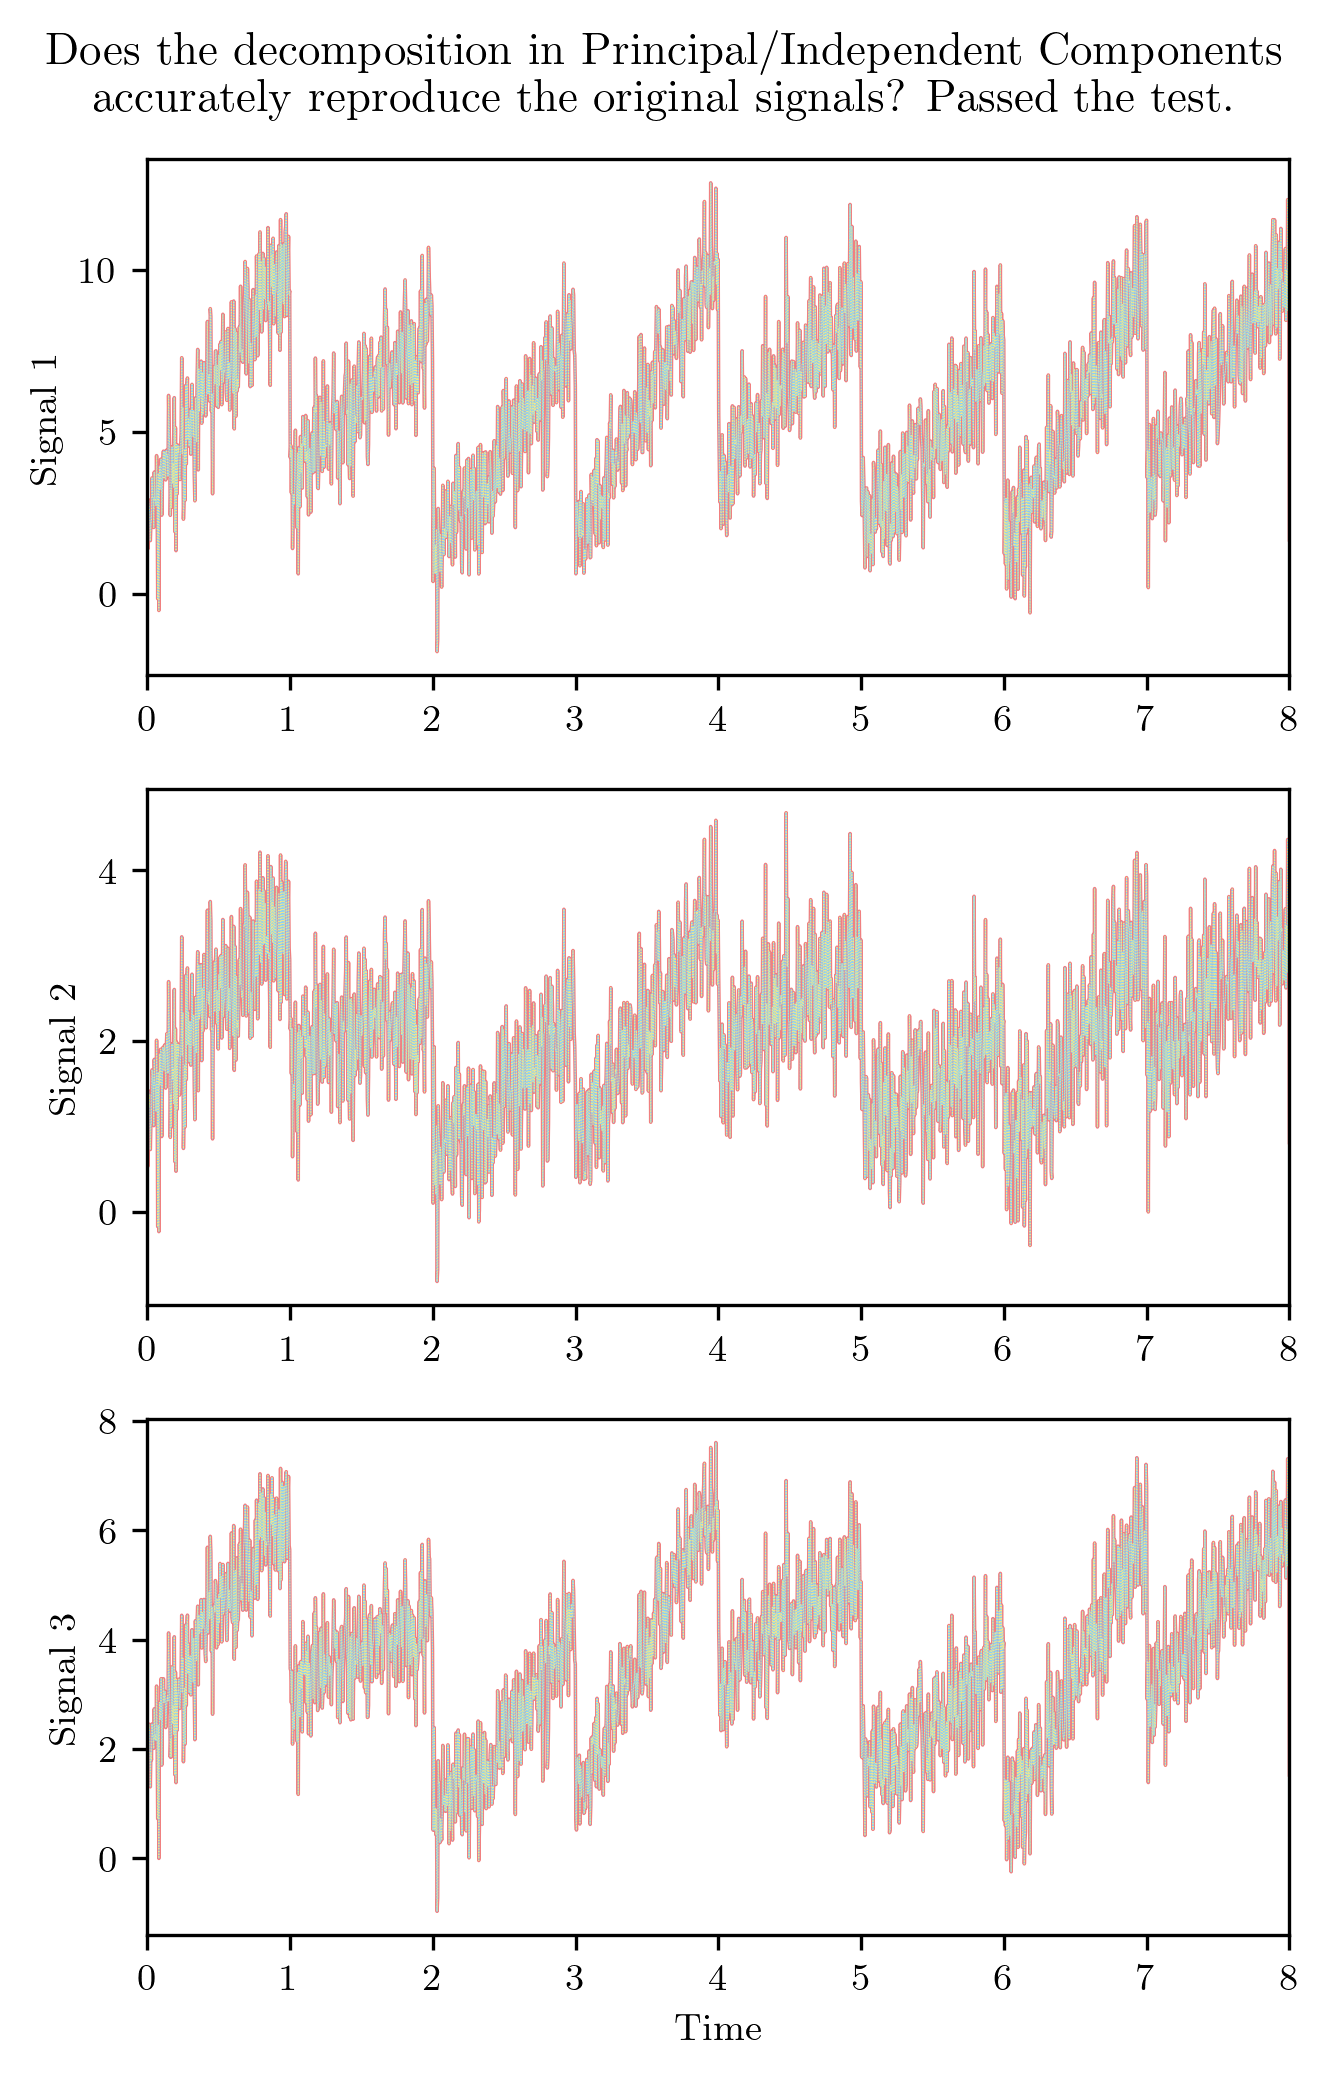

In [617]:
#-------------------------------------------------------------------------
# check that with the PCA decomposition we reconstruct the signals
#-------------------------------------------------------------------------

fig, ax = plt.subplots(3,1,figsize=(4.5,7))
    
for i in range(3):
    ax[i].plot(time, signal[:,i], color='lightcoral', lw=0.85)
    ax[i].set_xlim(0,8)
    ax[i].set_ylabel('Signal {:d}'.format(i+1))
ax[2].set_xlabel('Time')

for i in range(PCA1_n_components):
    comp = np.full_like(signal[:,i], np.mean(signal[:,i]))
    for j in range(PCA1_n_components):
        comp += np.copy(PCA1_eigenvalues[:,j]) * np.copy(PCA1_components[j,i])
    ax[i].plot(time, comp, color='lightskyblue', lw=0.25)
    del comp

for i in range(ICA1_n_components):
    comp = np.full_like(signal[:,i], np.mean(signal[:,i]))
    for j in range(ICA1_n_components):
        comp += np.copy(np.copy(ICA1_mixing[i,j] * ICA1_eigenvalues[:,j]))
    ax[i].plot(time, comp, color='khaki', lw=0.25, ls=':')
    del comp

for i in range(NMF1_n_components):
    comp = np.full_like(signal[:,i], 0)
    for j in range(NMF1_n_components):
        comp += np.copy(NMF1_eigenvalues[:,j]) * np.copy(NMF1_components[j,i])
    # ax[i].plot(time, comp, color='black', lw=0.25, ls=':')
    del comp

fig.suptitle('Does the decomposition in Principal/Independent Components\naccurately reproduce the original signals? Passed the test.')

fig.tight_layout()

#-------------------------------------------------------------------------

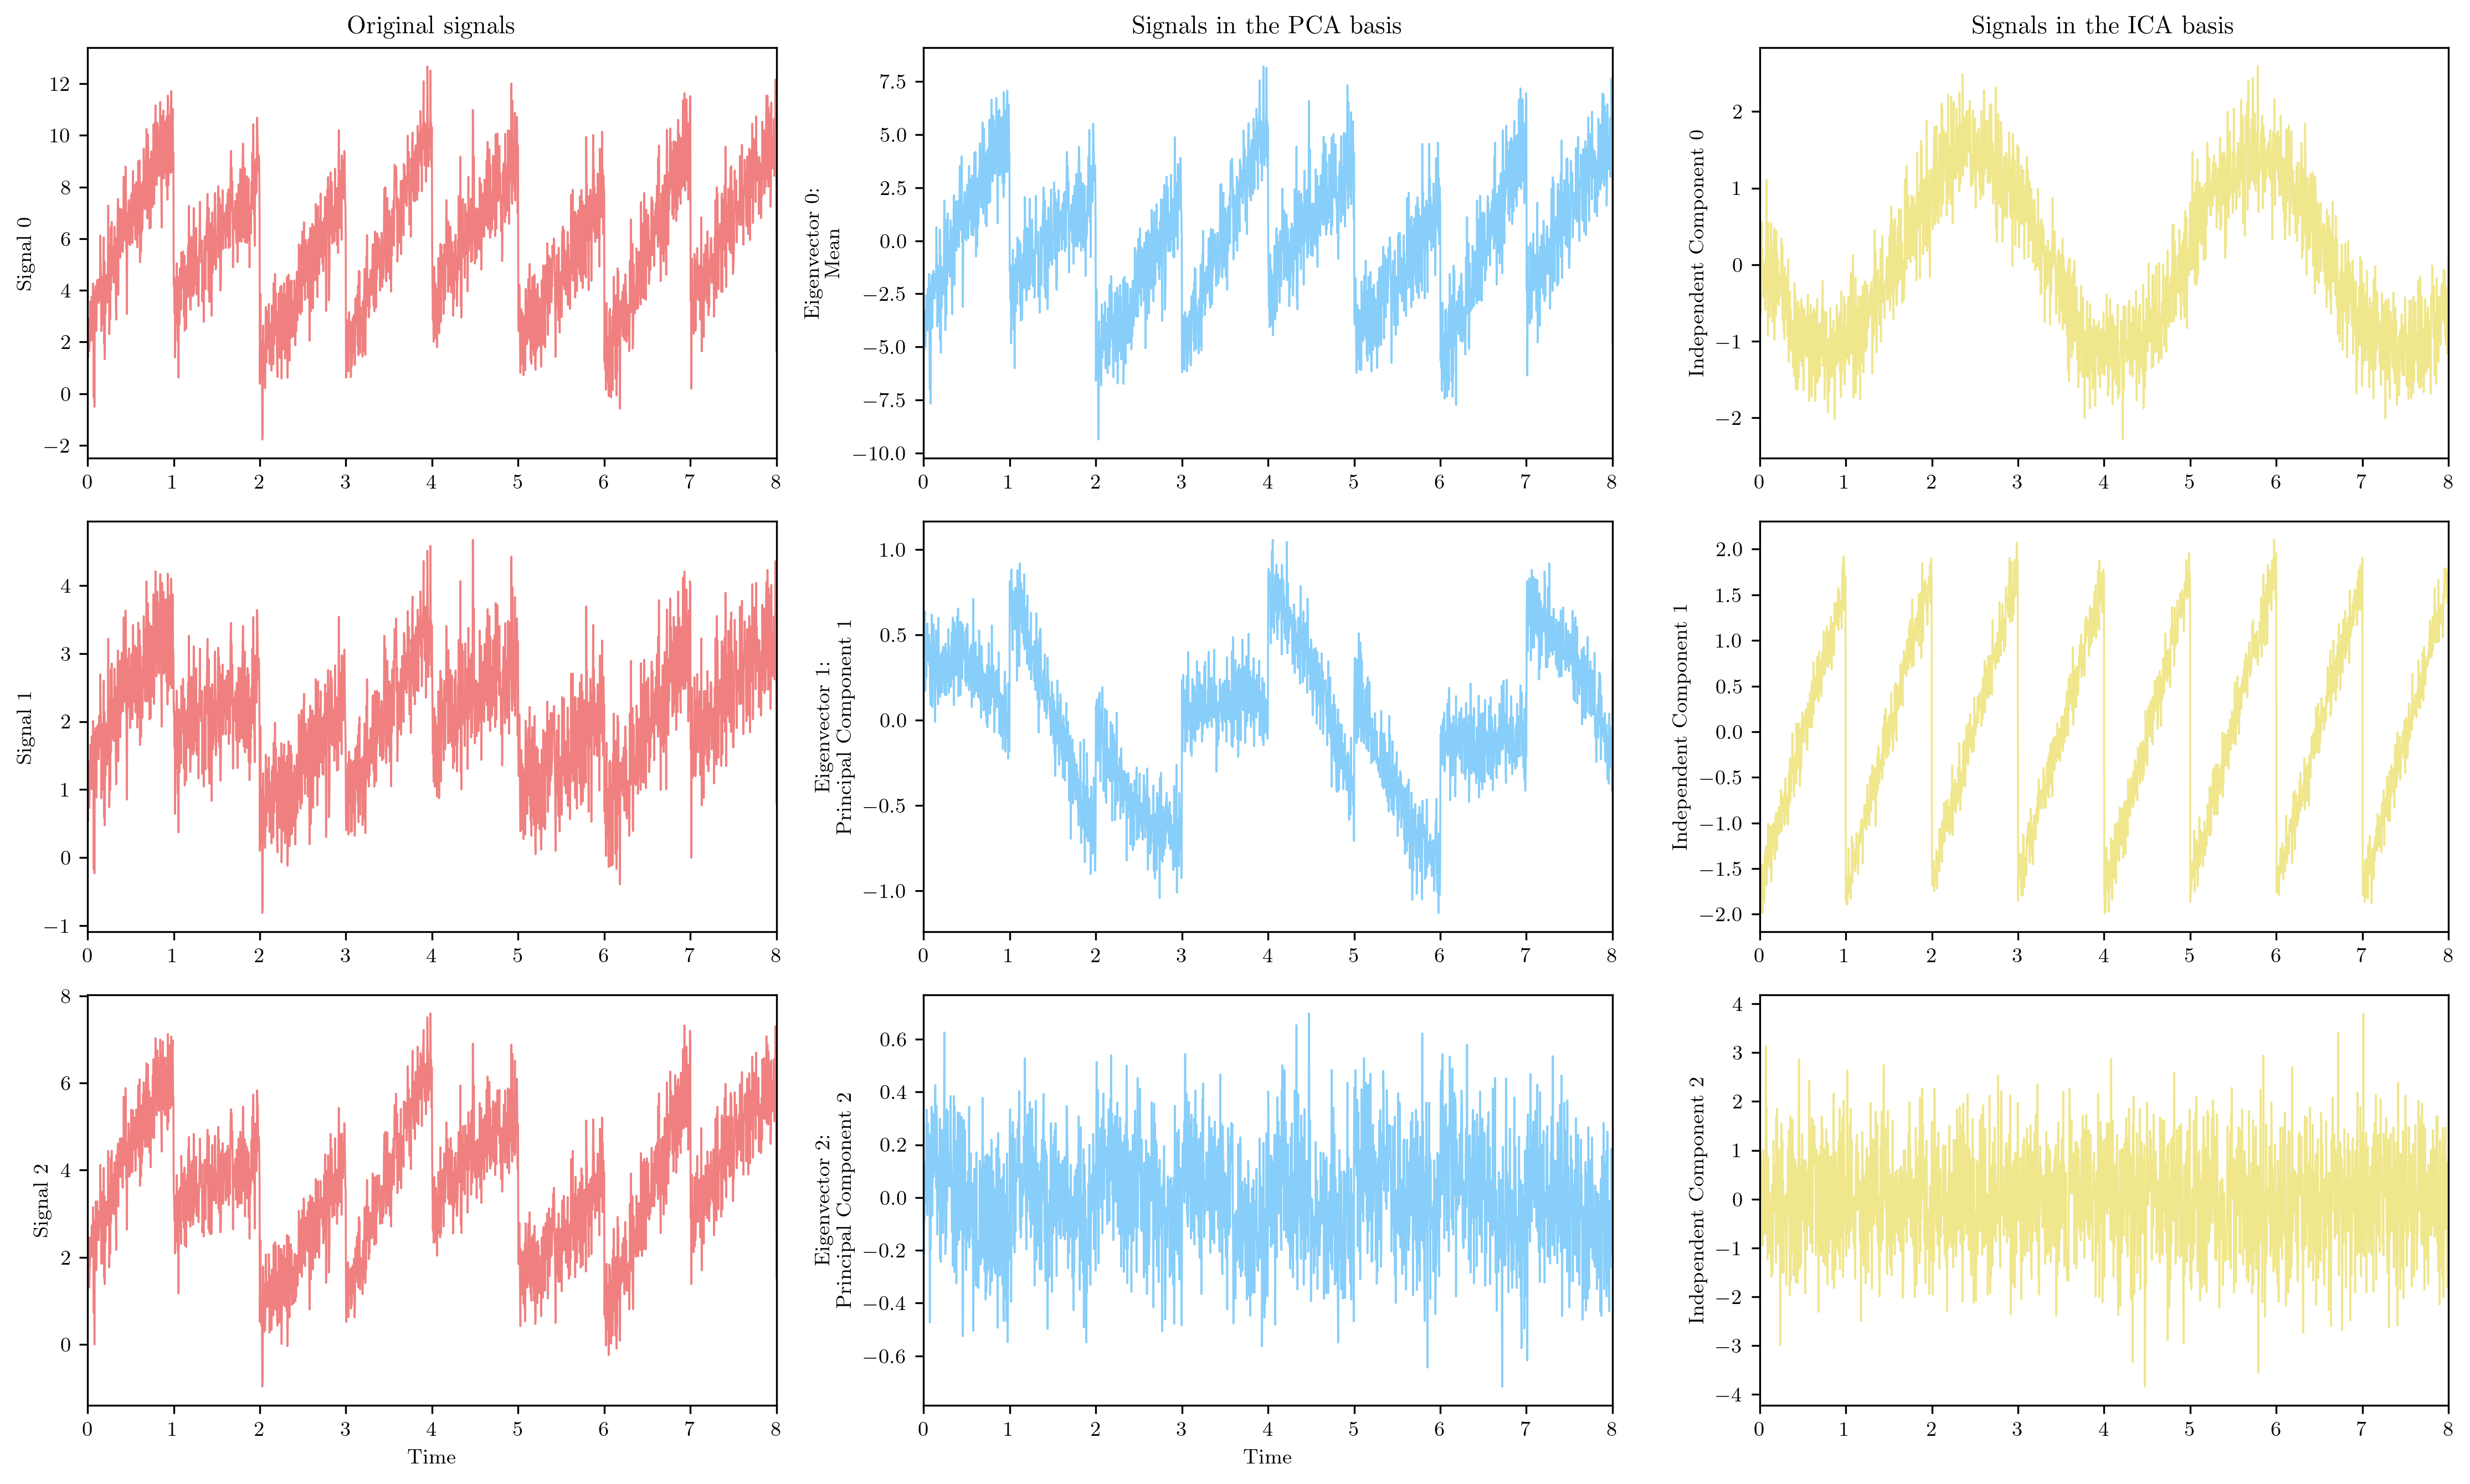

In [626]:
#-------------------------------------------------------------------------
# plot the three eigenvectors of the PCA and ICA bases
#-------------------------------------------------------------------------

fig, ax = plt.subplots(3,3,figsize=(15,9))


color = ['lightcoral','lightskyblue','khaki']
for i in range(PCA1_n_components):
    for j in [0,1,2]:
        ax[i,j].set_xlim(0,8)
        if j==1:
            ax[i,j].plot(time, PCA1_eigenvalues[:,i], color=color[j], lw=0.85)
            if i==0:
                ax[i,j].set_ylabel('Eigenvector {:d}:\nMean'.format(i))
                ax[i,j].set_title('Signals in the PCA basis')
            else:
                ax[i,j].set_ylabel('Eigenvector {:d}:\nPrincipal Component {:d}'.format(i,i))
        elif j==2:
            ax[i,j].plot(time, ICA1_eigenvalues[:,i], color=color[j], lw=0.85)
            ax[i,j].set_ylabel('Independent Component {:d}'.format(i))
            if i==0:
                ax[i,j].set_title('Signals in the ICA basis')
        else:
            ax[i,j].plot(time, signal[:,i], color=color[j], lw=0.85)
            ax[i,j].set_ylabel('Signal {:d}'.format(i))
            if i==0:
                ax[i,j].set_title('Original signals')
        
ax[-1,0].set_xlabel('Time')
ax[-1,1].set_xlabel('Time')
# ax[0].plot(time, signal_mean[0,:], color='lightskyblue', lw=0.85)

# fig.suptitle('Base of PCA and ICA eigenvectors')
fig.tight_layout()

#-------------------------------------------------------------------------

In [ ]:
#-------------------------------------------------------------------------
# this would have been the procedure IF we had a case like lecture 15: 
# independent measures of different wavefunctions
# there: n_features = value of wavefunction at timestep
#        n_samples  = number of wavefunctions
#        0-th eigenvector = the average wavefunction
#        i-th eigenvector = principal components = some wavefunctions that explain the most variance (common features)
#        i-th eigenvalue  = expansion of individual signal in terms of i-th eigenfunction 
#        individual wavefunction = mean wavefunction + sum_i eigenvalue_i eigenfunction_i 

#-------------------------------------------------------------------------
# Principal Component Analysis

def decompose_PCA_independent_measurements(data, n_components=3):
    # data.shape = ( n_samples = n_wavefunctions, n_features = n_timesteps) = (3, 2000)
    pca = PCA(n_components-1)
    data_eigenvalues = pca.fit_transform(data)         # eigenvalues for non-mean eigenfunctions (2 for each of 3 measurements)
    n_comps          = pca.n_components_               # in the default case, 2 eigenfunctions
    data_components  = pca.components_                 # eigenvector wavefunctions ( 2 of size 2000 )
    data_explvarrat  = pca.explained_variance_ratio_   # ratio of total variance each eigenvector accounts for 
    data_mean        = np.mean(data, axis=0)[:,np.newaxis].T  # the 0-th eigenvector (with eigenvalue = 1)

    return n_comps, data_mean, data_components, data_eigenvalues, data_explvarrat

#-------------------------------------------------------------------------
# Non-negative Matrix Factorization

def decompose_NMF_independent_measurements(data, n_components=3):       
    # data X = WY  Y = matrix with the n_comp vector (the positive components)

    dataset = np.copy(data)
    dataset[dataset<0]=0
    nmf = NMF(n_components)
    data_eigenvalues = nmf.fit_transform(dataset)
    data_components  = nmf.components_
    n_comps          = nmf.n_components_

    return n_comps, data_components, data_eigenvalues

#-------------------------------------------------------------------------
# Independent Component Analysis

def decompose_ICA_independent_measurements(data, n_components=3):

    ica = FastICA(n_components-1)
    data_eigenvalues = ica.fit_transform(data)
    data_components  = ica.components_
    data_mixing      = ica.mixing_
    data_mean        = ica.mean_
    n_comps          = n_components-1

    return n_comps, data_mean, data_components, data_eigenvalues, data_mixing

print('PCA, n_components:    (following lec15)')
print('{:d} + 1 (mean)'.format(PCA1_n_components))
print('signal shape: n_samples=3 vectors of n_features=2000')
print(signal.shape)
print('1st eigenvector = mean of 3 signals: 1 vector of n_f=2000')
print(signal_mean1.shape)
print('2nd, 3rd eigenvectors: 2 vectors of n_f=2000')
print(PCA1_components.shape)
print('transformed data: (3 sets of 2 eigenvalues)')
print(PCA1_eigenvalues.shape)
print('percentage of variance encoded in the 2 eigenvalues other than the mean')
print(PCA1_explvarrat.shape)
print(PCA1_explvarrat)
print()
print('transformed data method 2:')
print(PCA1_transform.shape)
print()
print()
print('NMF, n_components:')
print('{:d}'.format(NMF1_n_components))
print('signal shape: n_samples=3 vectors of n_features=2000')
print(signal.shape)
print('1st, 2nd, 3rd eigenvectors: 3 vectors of n_f=2000')
print(NMF1_components.shape)
print('transformed data: (3 sets of 3 eigenvalues)')
print(NMF1_eigenvalues.shape)
print()
print()
print('ICA, n_components:')
print('{:d}'.format(ICA1_n_components))
print('signal shape: n_samples=3 vectors of n_features=2000')
print(signal.shape)
print('1st, 2nd, 3rd eigenvectors: 3 vectors of n_f=2000')
print(ICA1_components.shape)
print('transformed data: (3 sets of 3 eigenvalues)')
print(ICA1_eigenvalues.shape)